# Avance 3 – Baseline
## Proyecto Integrador – Equipo 22

Integrantes:
*   María Virginia Mendizábal Miranda - A01796588
*   Gianmel Joannelly Hernandez Tosta - A01795919
*   Sofía Ordaz López - A01173717

**Proyecto:** Análisis de biomarcadores lipidómicos y metabolómicos mediante modelos de *machine learning* interpretativo para clasificación multiclase de cáncer colorrectal.

### Modelo baseline para clasificación multiclase de cáncer colorrectal mediante biomarcadores lipidómicos y metabolómicos


# 1. Objetivo del baseline

El objetivo de esta fase es construir un modelo baseline capaz de discriminar entre los grupos clínicos CTRL, AA y CRC utilizando biomarcadores lipidómicos y metabolómicos previamente seleccionados.

El baseline permitirá:
- evaluar la viabilidad predictiva del problema,
- establecer un punto de referencia para modelos futuros,
- analizar la relevancia de las características,
- e identificar posibles signos de subajuste o sobreajuste.

Dado el enfoque interpretativo del proyecto, se priorizaron modelos supervisados con alta interpretabilidad y bajo riesgo de sobreajuste.

In [1]:
# ============================================================
# Librerías
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    learning_curve
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


Con base en la retroalimentación recibida durante la fase de ingeniería de características (Avance 2), se redujo el espacio de variables para evitar redundancia biológica y sobre-ingeniería.

La matriz de entrada `X_intersect` proviene del Avance 2 y contiene:
- biomarcadores robustos comunes entre **ANOVA F-test** y **Mutual Information** (criterios supervisados con supuestos distintos),
- variables clínicas relevantes (`age`, `fit_ug_g`),
- y variables categóricas codificadas (`gender_Male`, `fob_YES`).

No se incluyen:
- componentes PCA (mantenidos en el Avance 2 únicamente como herramienta exploratoria),
- variables derivadas redundantes,
- ni múltiples niveles simultáneos de agregación biológica.

Conforme a CRISP-ML(Q), esta libreta **consume directamente la salida validada del Avance 2** (`avance2_X_intersect.csv` + `avance2_y.csv`), sin re-aplicar imputación ni escalamiento — ambas operaciones quedaron cerradas en la fase de Data Preparation.


In [2]:
# ============================================================
# 2. Carga del dataset final desde el Avance 2
# ============================================================
# Las matrices X_intersect y y se construyeron y exportaron en el Avance 2 tras:
#   - limpieza inicial
#   - imputación por mediana de grupo (validada contra MICE)
#   - codificación One-Hot
#   - transformación Box-Cox sobre continuas positivas
#   - escalamiento (StandardScaler)
#   - selección supervisada (intersección MI ∩ ANOVA + clínicas + categóricas)

from pathlib import Path

DATA_DIR = Path('.').resolve()

X = pd.read_csv(DATA_DIR / 'avance2_X_intersect.csv')
y = pd.read_csv(DATA_DIR / 'avance2_y.csv')['group']

print(f'Ruta de datos: {DATA_DIR}')
print(f'X_intersect shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nDistribución de clases:')
print(y.value_counts().to_dict())


Ruta de datos: /Users/sofiaordazlopez/Documents/Proyecto Integrador/notebooks
X_intersect shape: (211, 16)
y shape: (211,)

Distribución de clases:
{'CTRL': 78, 'CRC': 75, 'AA': 58}


In [3]:
# ============================================================
# Información general del dataset preprocesado
# ============================================================

clinical_cols = [c for c in ['age', 'fit_ug_g'] if c in X.columns]
categorical_cols = [c for c in X.columns if c.startswith(('gender_', 'fob_'))]
lipid_cols = [c for c in X.columns if c not in clinical_cols + categorical_cols]

print(f'Número de muestras: {X.shape[0]}')
print(f'Número total de variables predictoras: {X.shape[1]}')
print(f'\nVariables clínicas ({len(clinical_cols)}): {clinical_cols}')
print(f'Variables categóricas ({len(categorical_cols)}): {categorical_cols}')
print(f'Biomarcadores lipidómicos ({len(lipid_cols)}): {lipid_cols}')
print(f'\nValores faltantes restantes: {X.isna().sum().sum()}')

X.head()


Número de muestras: 211
Número total de variables predictoras: 16

Variables clínicas (2): ['age', 'fit_ug_g']
Variables categóricas (2): ['gender_Male', 'fob_YES']
Biomarcadores lipidómicos (12): ['CE(20:5)', 'GlcCer(d18:1/24:0)', 'PC(36:5)', 'PC(O-16:0/16:0)', 'PC(O-16:0/18:2)', 'PC(O-34:1)', 'SM(33:1)', 'SM(42:3)', 'SM(d18:1/22:0)', 'SM(d18:1/23:0)', 'SM(d18:1/24:1) + SM(d18:2/24:0)', 'TG(51:4)']

Valores faltantes restantes: 0


,CE(20:5),GlcCer(d18:1/24:0),PC(36:5),PC(O-16:0/16:0),PC(O-16:0/18:2),PC(O-34:1),SM(33:1),SM(42:3),SM(d18:1/22:0),SM(d18:1/23:0),SM(d18:1/24:1) + SM(d18:2/24:0),TG(51:4),fit_ug_g,age,gender_Male,fob_YES
0,0.883784,1.430422,0.155875,3.789349,2.012357,2.424742,2.487655,2.409375,2.316616,2.324193,2.588410,0.097011,-1.025573,0.114724,1,0
1,0.010448,0.253402,-0.203939,-0.419051,1.994415,0.782273,1.306299,-0.448485,0.272724,0.008021,0.179774,0.424891,1.251480,0.575455,0,1
2,0.306966,0.403584,-1.587194,0.463327,-0.391872,0.193911,0.493873,0.029096,-0.675153,0.496688,0.144890,-1.950313,1.251480,-0.950829,1,1
3,1.810424,-0.136626,1.223409,0.366599,1.001063,1.044246,0.149334,0.263777,-0.025028,-0.045723,0.488084,-0.178296,1.251480,1.080670,1,1
4,-0.568229,0.253402,-0.203939,-0.672886,-0.505652,-1.011195,-1.605365,-0.300000,-1.093585,-0.265947,-0.145450,0.035715,-1.025573,-0.222776,0,0


# 3. Verificación del dataset

Dado que el Avance 2 cerró la fase de **Data Preparation** de CRISP-ML(Q), esta libreta **no aplica imputación ni escalamiento adicional**. La matriz `X_intersect` ya está:

- imputada por mediana de grupo (decisión validada contra MICE en el Avance 1),
- codificada (`gender` y `fob` como dummies),
- transformada con Box-Cox sobre continuas estrictamente positivas,
- y escalada con `StandardScaler`.

A continuación se verifica únicamente que la matriz esté completa y lista para el modelado.


In [4]:
# ============================================================
# Verificación de integridad de la matriz de entrada
# ============================================================

assert X.isna().sum().sum() == 0, 'X contiene valores faltantes; revisar Avance 2'
assert y.isna().sum() == 0, 'y contiene valores faltantes'
assert X.shape[0] == y.shape[0], 'X y y no tienen el mismo número de filas'

print('Verificaciones aprobadas:')
print(f'  - Sin valores faltantes en X ni en y')
print(f'  - X y y alineadas ({X.shape[0]} muestras)')
print(f'  - {X.shape[1]} variables predictoras listas para el modelado')


Verificaciones aprobadas:
  - Sin valores faltantes en X ni en y
  - X y y alineadas (211 muestras)
  - 16 variables predictoras listas para el modelado


# 4. Selección del algoritmo baseline

Se seleccionó Regresión Logística Multiclase como modelo baseline debido a que:

- el conjunto de datos es tabular y relativamente pequeño,
- el número de muestras es limitado respecto al número de variables,
- el problema corresponde a clasificación multiclase supervisada,
- y el proyecto prioriza interpretabilidad biomédica sobre complejidad algorítmica.

La regresión logística permite:
- interpretar coeficientes,
- analizar importancia relativa de biomarcadores,
- reducir riesgo de sobreajuste,
- y establecer una referencia clara para modelos más complejos en etapas posteriores.

Además, es ampliamente utilizada como baseline en problemas biomédicos debido a su estabilidad y facilidad de interpretación.

# 5. Métricas de evaluación

### Justificación de la métrica principal: **Macro F1-score**

El problema tiene tres particularidades que orientan la elección de la métrica:

1. **Multiclase con desbalance moderado** — Las proporciones son CTRL=37%, CRC=36%, AA=27%. Métricas como `accuracy` o `precision_micro` están sesgadas hacia las clases mayoritarias.
2. **La clase minoritaria (AA) es la clínicamente prioritaria** — AA (adenoma avanzado) es la **lesión precancerosa**: detectarla a tiempo es justamente la ventana de intervención que permite **prevenir** la progresión a CRC mediante polipectomía colonoscópica. Un modelo que ignora AA falla precisamente donde el sistema de salud puede aportar más valor.
3. **El estándar actual (FIT solo) tiene baja sensibilidad para AA** — Según el paper de origen (Albóniga et al., 2025), 20 de 58 pacientes con AA (≈34%) reciben **falso negativo** por FIT. Existe entonces una necesidad clínica clara de mejorar la detección de AA con biomarcadores complementarios.

**Macro F1-score** promedia el F1 de cada clase con **peso igual**, evitando que un buen desempeño en CTRL y CRC enmascare la incapacidad de detectar AA. Es la métrica que mejor alinea evaluación técnica con utilidad clínica.

### Métricas complementarias reportadas

| Métrica | Para qué se usa |
|---|---|
| **Accuracy** | Comparación rápida vs azar (1/3 = 33%) |
| **Precision macro** | Detectar si el modelo está siendo "demasiado agresivo" en alguna clase (muchos falsos positivos) |
| **Recall macro** | Detectar si el modelo está omitiendo casos de alguna clase (muchos falsos negativos) — crítico para AA y CRC |
| **Matriz de confusión** | Identificar errores **sistemáticos** entre grupos (p. ej., confundir AA con CTRL es peor clínicamente que confundir AA con CRC) |
| **Classification report por clase** | Verificar que ninguna clase quede con F1 ≈ 0, como ocurrió en el paper para AA con PLS-DA |


In [5]:
# ============================================================
# Verificación de distribución de clases
# ============================================================

class_distribution = y.value_counts().to_frame(name='n')
class_distribution['proportion'] = y.value_counts(normalize=True)

class_distribution

,n,proportion
group,,
CTRL,78,0.369668
CRC,75,0.355450
AA,58,0.274882


In [6]:
# ============================================================
# Métrica principal seleccionada
# ============================================================

primary_metric = 'f1_macro'

print(f"Métrica principal seleccionada: {primary_metric}")

Métrica principal seleccionada: f1_macro


# 6. Desempeño mínimo esperado

### Existe histórico parcial: Albóniga et al. (2025) sobre el mismo dataset

El paper de origen del dataset (mismas 211 muestras) publica benchmarks de modelos predictivos, lo que permite establecer un piso de desempeño **histórico verificable**, no solo el baseline aleatorio.

**Histórico binario (Random Forest con FIT + Cholesteryl Esters, Tabla 5 del paper):**

| Comparación binaria | F1-Score | AUC ROC |
|---|---|---|
| CRC vs CTRL | 89.6 | 91 |
| CRC vs AA | 83.3 | 81 |
| AA vs CTRL | 78.5 | 70 |

**Histórico multiclase (PLS-DA con FIT + CEs, Tabla 6 y Figura 3 del paper):**

> *"The highest misclassification ratio was obtained for the AA group, where **none of the samples were classified as AA**."* (Albóniga et al., 2025, p. 13)

Es decir: el propio paper reconoce que su modelo 3-clases (PLS-DA) **no logra discriminar AA en absoluto**. CRC se clasifica al 98% y CTRL al 95%, pero AA cae a 0% de aciertos.

### Desempeño mínimo aceptable para este baseline

A partir del histórico se definen dos pisos:

| Referencia | Métrica | Umbral mínimo |
|---|---|---|
| **Baseline aleatorio (lower bound)** | F1-macro | > **1/3 = 0.333** |
| **Histórico multiclase del paper (PLS-DA)** | F1 sobre AA | > **0** (cualquier capacidad de detectar AA supera al estado del arte 3-clases) |
| **Histórico binario del paper (RF)** | F1 promedio binario | ≈ **0.84** (techo aspiracional para fases posteriores; no exigible al baseline multiclase) |

El baseline propuesto se considerará **aceptable** si:
- Macro F1 de validación supera claramente el azar (1/3),
- Cada clase obtiene F1 > 0 (es decir, el modelo no colapsa hacia las clases mayoritarias como hizo PLS-DA),
- La brecha train-validation es moderada (sin sobreajuste fuerte).

Las verificaciones cuantitativas se ejecutan a continuación.


In [7]:
# ============================================================
# Baseline aleatorio esperado
# ============================================================

n_classes = y.nunique()
random_baseline = 1 / n_classes

print(f"Número de clases: {n_classes}")
print(f"Desempeño esperado por azar: {random_baseline:.3f}")

Número de clases: 3
Desempeño esperado por azar: 0.333


# 7. Validación cruzada estratificada

### Por qué validación cruzada y no un split train/test simple

El dataset cuenta con únicamente **211 muestras** (CTRL=78, CRC=75, AA=58). Bajo un split simple 80/20, el conjunto de prueba quedaría con apenas ~42 observaciones — una muestra demasiado pequeña para estimar el desempeño con baja varianza, especialmente para la clase minoritaria (AA) donde habría ~12 ejemplos. La **validación cruzada de k-folds** mitiga este problema reutilizando los datos: cada muestra participa una vez como validación y k-1 veces como entrenamiento, produciendo una estimación más estable del error de generalización (Kohavi, 1995; Hastie et al., 2009).

### Por qué *estratificada* en particular

El target es multiclase con **desbalance moderado** (proporciones aprox. 37% CTRL / 36% CRC / 27% AA). Un `KFold` estándar puede generar folds en los que la clase minoritaria (AA) quede sobre- o sub-representada, lo cual:

- sesga la métrica `F1-macro` (sensible al desempeño por clase),
- introduce varianza adicional entre folds, y
- en casos extremos puede dejar una clase **ausente** del fold de validación, impidiendo calcular precisión/recall para ella.

`StratifiedKFold` resuelve esto preservando en cada fold la **proporción original de las tres clases**, lo que es la práctica estándar recomendada para clasificación con clases desbalanceadas (Géron, 2022; sklearn user guide §3.1.4).

### Justificación de los hiperparámetros

| Parámetro | Valor | Razón |
|---|---|---|
| `n_splits` | **5** | Compromiso estándar entre sesgo y varianza. Con `k=10` cada fold de validación tendría ~21 muestras (muy poco para AA: ~6 ejemplos), elevando la varianza. Con `k=3` el entrenamiento usaría solo 2/3 de los datos, sesgando el desempeño hacia abajo (Hastie et al., 2009, §7.10). `k=5` deja ~42 muestras por fold de validación (~12 de AA), suficiente para métricas estables. |
| `shuffle` | **True** | El orden original del dataset no es informativo (no es serie temporal ni tiene agrupamientos jerárquicos como pacientes con múltiples muestras). Mezclar antes de partir evita estructura espuria en los folds (p. ej., si los grupos estuvieran ordenados secuencialmente). |
| `random_state` | **42** | Fija la semilla del mezclado para que los folds sean **reproducibles** entre corridas — requisito explícito de CRISP-ML(Q) para que la evaluación sea auditable. |

### Conexión con CRISP-ML(Q)

Esta elección de validación atiende el quality gate de la fase de **Evaluation**: producir una estimación de desempeño *robusta, reproducible y comparable* contra modelos posteriores. El uso de `cross_validate` con `return_train_score=True` permite además contrastar entrenamiento vs validación para diagnosticar sub/sobre-ajuste (sección 8) sin necesidad de un tercer conjunto.

> **Referencias:**
> Kohavi, R. (1995). *A study of cross-validation and bootstrap for accuracy estimation and model selection.* IJCAI.
> Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed., §7.10). Springer.
> Géron, A. (2022). *Hands-On Machine Learning* (3rd ed., cap. 3). O'Reilly.


In [8]:
# ============================================================
# Validación cruzada
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# multi_class por defecto desde sklearn >=1.5; no se pasa explícitamente
# para evitar FutureWarning de deprecación.
model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

scoring = [
    'accuracy',
    'precision_macro',
    'recall_macro',
    'f1_macro'
]

cv_results = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

results = pd.DataFrame(cv_results)

results.head()


,fit_time,score_time,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro,test_f1_macro,train_f1_macro
0,0.005268,0.002311,0.627907,0.732143,0.617934,0.718139,0.613889,0.712903,0.609078,0.711786
1,0.001659,0.001871,0.619048,0.710059,0.515686,0.699099,0.566414,0.695123,0.530093,0.694130
2,0.001641,0.001822,0.690476,0.698225,0.651852,0.682880,0.657323,0.680401,0.652288,0.678325
3,0.001672,0.001937,0.547619,0.733728,0.517989,0.724025,0.527778,0.713757,0.520028,0.713331
4,0.001770,0.001822,0.642857,0.733728,0.648773,0.719699,0.633333,0.716241,0.627687,0.715704


In [9]:
# ============================================================
# Resultados promedio
# ============================================================

summary_results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision Macro',
        'Recall Macro',
        'F1 Macro'
    ],
    'Train Mean': [
        results['train_accuracy'].mean(),
        results['train_precision_macro'].mean(),
        results['train_recall_macro'].mean(),
        results['train_f1_macro'].mean()
    ],
    'Validation Mean': [
        results['test_accuracy'].mean(),
        results['test_precision_macro'].mean(),
        results['test_recall_macro'].mean(),
        results['test_f1_macro'].mean()
    ]
})

summary_results

,Metric,Train Mean,Validation Mean
0,Accuracy,0.721577,0.625581
1,Precision Macro,0.708768,0.590447
2,Recall Macro,0.703685,0.599747
3,F1 Macro,0.702655,0.587835


La diferencia observada entre métricas de entrenamiento y validación fue moderada, lo que sugiere que el modelo mantiene una capacidad razonable de generalización sin evidencias fuertes de sobreajuste.

Además, el desempeño de validación superó claramente el baseline aleatorio esperado para un problema multiclase de tres categorías.

In [10]:
# ============================================================
# Comparación contra desempeño mínimo esperado
# ============================================================

baseline_f1 = summary_results.loc[
    summary_results['Metric'] == 'F1 Macro',
    'Validation Mean'
].values[0]

print(f"Macro F1 del baseline: {baseline_f1:.3f}")
print(f"Desempeño mínimo esperado por azar: {random_baseline:.3f}")

if baseline_f1 > random_baseline:
    print("El modelo baseline supera el desempeño esperado por azar.")
else:
    print("El modelo baseline NO supera el desempeño esperado por azar.")

Macro F1 del baseline: 0.588
Desempeño mínimo esperado por azar: 0.333
El modelo baseline supera el desempeño esperado por azar.


# 8. Evaluación de sub/sobreajuste

Se compararon las métricas obtenidas en entrenamiento y validación para identificar posibles signos de subajuste o sobreajuste.

Diferencias excesivas entre ambos conjuntos podrían indicar sobreajuste, mientras que desempeños bajos en ambos podrían sugerir subajuste.

In [11]:
# ============================================================
# Diagnóstico simple de sub/sobreajuste
# ============================================================

train_f1 = summary_results.loc[
    summary_results['Metric'] == 'F1 Macro',
    'Train Mean'
].values[0]

val_f1 = summary_results.loc[
    summary_results['Metric'] == 'F1 Macro',
    'Validation Mean'
].values[0]

gap = train_f1 - val_f1

print(f"F1 Macro entrenamiento: {train_f1:.3f}")
print(f"F1 Macro validación: {val_f1:.3f}")
print(f"Diferencia train-validation: {gap:.3f}")

if gap > 0.15:
    print("Posible sobreajuste: el desempeño en entrenamiento es considerablemente mayor que en validación.")
elif train_f1 < 0.40 and val_f1 < 0.40:
    print("Posible subajuste: el desempeño es bajo tanto en entrenamiento como en validación.")
else:
    print("No se observan signos fuertes de subajuste o sobreajuste.")

F1 Macro entrenamiento: 0.703
F1 Macro validación: 0.588
Diferencia train-validation: 0.115
No se observan signos fuertes de subajuste o sobreajuste.


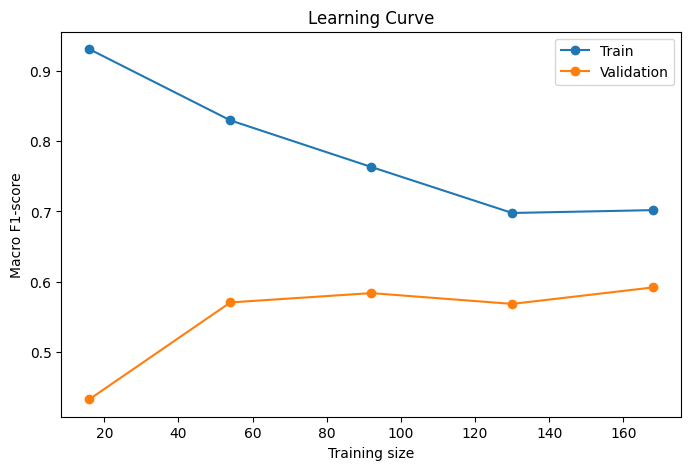

In [12]:
# ============================================================
# Curva de aprendizaje
# ============================================================

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X,
    y,
    cv=cv,
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean, marker='o', label='Train')
plt.plot(train_sizes, test_mean, marker='o', label='Validation')

plt.xlabel('Training size')
plt.ylabel('Macro F1-score')

plt.title('Learning Curve')

plt.legend()

plt.show()


# 9. Importancia de características

Debido a la naturaleza interpretable de la regresión logística, los coeficientes del modelo permiten analizar la contribución relativa de los biomarcadores en la clasificación multiclase.

In [13]:
# ============================================================
# Entrenamiento final
# ============================================================

model.fit(X, y)

coef_df = pd.DataFrame(
    model.coef_.T,
    index=X.columns,
    columns=model.classes_
)

coef_df.head()


,AA,CRC,CTRL
CE(20:5),0.320961,0.178847,-0.499809
GlcCer(d18:1/24:0),-0.041675,-0.260020,0.301695
PC(36:5),0.001378,0.105172,-0.106550
PC(O-16:0/16:0),-0.414017,0.521949,-0.107932
PC(O-16:0/18:2),-0.067340,0.177093,-0.109754


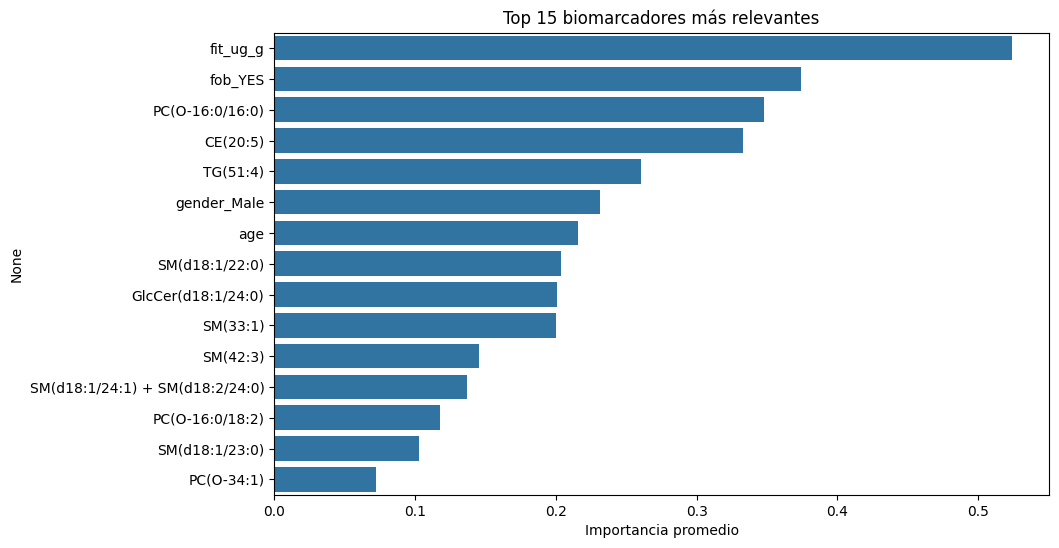

In [14]:
# ============================================================
# Importancia promedio
# ============================================================

importance = coef_df.abs().mean(axis=1)

importance = importance.sort_values(
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=importance.values[:15],
    y=importance.index[:15]
)

plt.title("Top 15 biomarcadores más relevantes")

plt.xlabel("Importancia promedio")

plt.show()

In [15]:
# ============================================================
# Tabla de importancia de características
# ============================================================

feature_importance_table = pd.DataFrame({
    'feature': importance.index,
    'importance_mean_abs_coef': importance.values
})

feature_importance_table.head(15)

,feature,importance_mean_abs_coef
0,fit_ug_g,0.524173
1,fob_YES,0.374209
2,PC(O-16:0/16:0),0.347966
3,CE(20:5),0.333206
4,TG(51:4),0.260707
5,gender_Male,0.231313
6,age,0.215614
7,SM(d18:1/22:0),0.203418
8,GlcCer(d18:1/24:0),0.201130
9,SM(33:1),0.200271


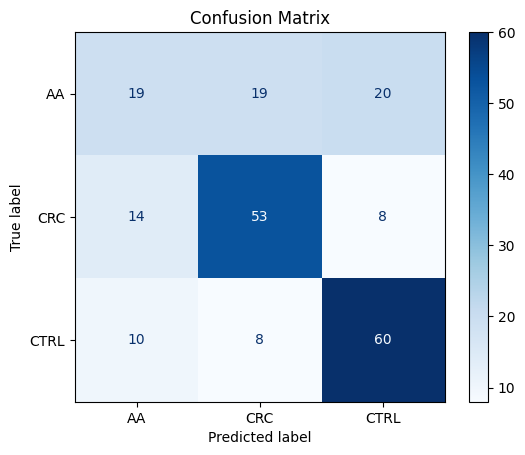

In [16]:
# ============================================================
# Matriz de confusión
# ============================================================

y_pred = cross_val_predict(
    model,
    X,
    y,
    cv=cv
)

cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix")

plt.show()


In [17]:
# ============================================================
# Reporte de clasificación
# ============================================================

print(classification_report(y, y_pred))

              precision    recall  f1-score   support

          AA       0.44      0.33      0.38        58
         CRC       0.66      0.71      0.68        75
        CTRL       0.68      0.77      0.72        78

    accuracy                           0.63       211
   macro avg       0.60      0.60      0.59       211
weighted avg       0.61      0.63      0.61       211



# 10. Interpretación preliminar

El modelo baseline obtuvo un Macro F1-score de validación superior al desempeño esperado por azar, lo que indica que los biomarcadores seleccionados contienen señal discriminativa para diferenciar entre CTRL, AA y CRC.

La matriz de confusión permite observar en qué clases el modelo presenta mayor o menor capacidad de discriminación. Esto es importante porque, en un contexto biomédico, no basta con evaluar el desempeño global; también es necesario revisar si existen errores sistemáticos entre grupos clínicamente relevantes.

La clase AA presentó menor desempeño relativo, lo cual sugiere que la discriminación entre adenoma avanzado y los otros grupos clínicos podría ser más compleja. Este resultado es relevante para etapas posteriores, donde modelos más flexibles podrían explorar patrones no lineales sin perder interpretabilidad.

El análisis de coeficientes de la regresión logística permitió identificar las variables con mayor contribución promedio al modelo. Dado que el dataset final fue reducido a biomarcadores robustos comunes entre ANOVA y Mutual Information, la importancia observada se interpreta como una señal preliminar de relevancia predictiva, no como evidencia causal.

En conjunto, el baseline muestra viabilidad predictiva y ofrece una referencia interpretable para comparar modelos más complejos en avances posteriores.

# 11. Validación de la estrategia de selección de variables

### Motivación (retroalimentación Dra. Grettel Barceló)

El baseline anterior se entrenó sobre `X_intersect` (16 features). Para validar que esta estrategia de selección **no descarta señal discriminativa**, esta sección entrena el mismo modelo (Regresión Logística Multiclase) sobre las **tres matrices candidatas** del Avance 2:

| Matriz | n_features | Estrategia |
|---|---|---|
| `X_full` | 131 | Sin filtros — referencia de información completa |
| `X_corr` | 127 | Filtro de correlación \|r\|>0.95 — sin redundancia |
| `X_intersect` | 16 | Intersección MI ∩ ANOVA + clínicas + categóricas |

Cada matriz se evalúa **con y sin** `class_weight='balanced'` para cuantificar también el impacto del balanceo en la detección de la clase minoritaria (**AA — adenoma avanzado**), que es clínicamente la más importante.

### Casos posibles (marco interpretativo)

Los resultados se contrastan contra los cuatro escenarios planteados por la Dra:

- **Caso 1**: `X_intersect` ≈ `X_corr` ≈ `X_full` → señal concentrada, filtrado supervisado es válido.
- **Caso 2**: `X_corr` ≈ `X_full`, `X_intersect` peor → variables débiles pero complementarias; descartar `X_intersect`.
- **Caso 3**: `X_intersect` ≈ `X_full`, `X_corr` peor → señal en variables redundantes; descartar `X_corr`.
- **Caso 4**: `X_full` mejor que todos → señal distribuida; ninguna estrategia de selección la captura.


In [18]:
# ============================================================
# Validación de la estrategia de selección de variables
# ============================================================
# Cargar las tres matrices candidatas
from pathlib import Path
DATA_DIR = Path('.').resolve()
X_full = pd.read_csv(DATA_DIR / 'avance2_X_full.csv')
X_corr = pd.read_csv(DATA_DIR / 'avance2_X_corr.csv')
X_intersect = pd.read_csv(DATA_DIR / 'avance2_X_intersect.csv')

matrices = {
    'X_full': X_full,
    'X_corr': X_corr,
    'X_intersect': X_intersect,
}

print('Matrices cargadas:')
for name, X_m in matrices.items():
    print(f'  {name}: {X_m.shape}')


Matrices cargadas:
  X_full: (211, 131)
  X_corr: (211, 127)
  X_intersect: (211, 16)


In [19]:
# ============================================================
# Evaluación: LogReg en las 3 matrices x 2 esquemas de balanceo
# ============================================================
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import recall_score

scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

selection_results = []

for cw_label, cw in [('sin balanceo', None), ('class_weight=balanced', 'balanced')]:
    for name, X_m in matrices.items():
        model_eval = LogisticRegression(
            max_iter=5000,
            class_weight=cw,
            random_state=42
        )

        scores = cross_validate(
            model_eval, X_m, y, cv=cv,
            scoring=scoring, return_train_score=True
        )

        # Recall AA via cross_val_predict
        y_pred_cv = cross_val_predict(model_eval, X_m, y, cv=cv)
        recall_AA = recall_score(y, y_pred_cv, labels=['AA'], average='macro', zero_division=0)
        recall_CRC = recall_score(y, y_pred_cv, labels=['CRC'], average='macro', zero_division=0)
        recall_CTRL = recall_score(y, y_pred_cv, labels=['CTRL'], average='macro', zero_division=0)

        selection_results.append({
            'Matriz': name,
            'n_features': X_m.shape[1],
            'Balanceo': cw_label,
            'F1 Macro': round(scores['test_f1_macro'].mean(), 4),
            'Train F1': round(scores['train_f1_macro'].mean(), 4),
            'Gap (Train-Val)': round(scores['train_f1_macro'].mean() - scores['test_f1_macro'].mean(), 4),
            'Accuracy': round(scores['test_accuracy'].mean(), 4),
            'Recall AA': round(recall_AA, 4),
            'Recall CRC': round(recall_CRC, 4),
            'Recall CTRL': round(recall_CTRL, 4),
        })

selection_df = pd.DataFrame(selection_results)
print('=== Resultados completos ===')
display(selection_df)


=== Resultados completos ===


,Matriz,n_features,Balanceo,F1 Macro,Train F1,Gap (Train-Val),Accuracy,Recall AA,Recall CRC,Recall CTRL
0,X_full,131,sin balanceo,0.6415,0.9962,0.3547,0.6539,0.5000,0.7333,0.6923
1,X_corr,127,sin balanceo,0.6445,0.9962,0.3517,0.6539,0.5345,0.7067,0.6923
2,X_intersect,16,sin balanceo,0.5878,0.7027,0.1148,0.6256,0.3276,0.7067,0.7692
3,X_full,131,class_weight=balanced,0.6289,1.0000,0.3711,0.6398,0.5172,0.7067,0.6667
4,X_corr,127,class_weight=balanced,0.6313,1.0000,0.3687,0.6398,0.5345,0.6800,0.6795
5,X_intersect,16,class_weight=balanced,0.6277,0.7145,0.0868,0.6494,0.4655,0.6933,0.7436


In [20]:
# ============================================================
# Resumen: pivot por matriz x esquema de balanceo
# ============================================================
print('=== F1-macro (validación cruzada) ===')
pivot_f1 = selection_df.pivot(index='Matriz', columns='Balanceo', values='F1 Macro')
display(pivot_f1)

print('\n=== Recall AA (clase clínicamente prioritaria) ===')
pivot_aa = selection_df.pivot(index='Matriz', columns='Balanceo', values='Recall AA')
display(pivot_aa)

print('\n=== Gap Train-Val (indicador de sobreajuste) ===')
pivot_gap = selection_df.pivot(index='Matriz', columns='Balanceo', values='Gap (Train-Val)')
display(pivot_gap)


=== F1-macro (validación cruzada) ===


Balanceo,class_weight=balanced,sin balanceo
Matriz,,
X_corr,0.6313,0.6445
X_full,0.6289,0.6415
X_intersect,0.6277,0.5878



=== Recall AA (clase clínicamente prioritaria) ===


Balanceo,class_weight=balanced,sin balanceo
Matriz,,
X_corr,0.5345,0.5345
X_full,0.5172,0.5000
X_intersect,0.4655,0.3276



=== Gap Train-Val (indicador de sobreajuste) ===


Balanceo,class_weight=balanced,sin balanceo
Matriz,,
X_corr,0.3687,0.3517
X_full,0.3711,0.3547
X_intersect,0.0868,0.1148


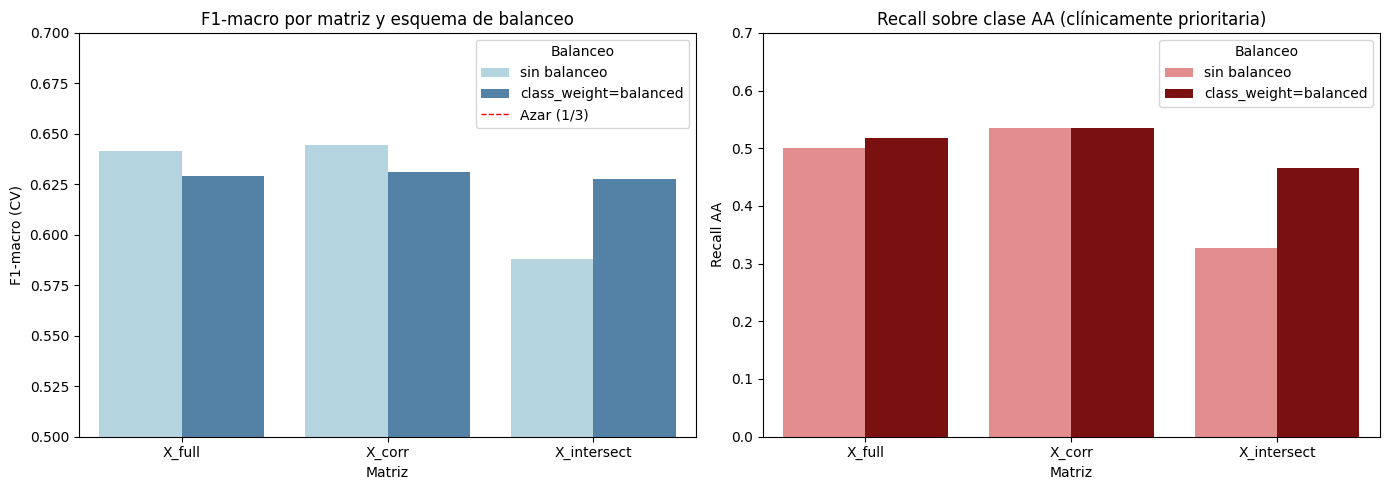

In [21]:
# ============================================================
# Visualización comparativa
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1-macro
sns.barplot(
    data=selection_df, x='Matriz', y='F1 Macro', hue='Balanceo',
    ax=axes[0], palette=['lightblue','steelblue']
)
axes[0].set_title('F1-macro por matriz y esquema de balanceo')
axes[0].set_ylabel('F1-macro (CV)')
axes[0].set_ylim(0.5, 0.7)
axes[0].axhline(0.333, color='red', linestyle='--', label='Azar (1/3)', linewidth=1)
axes[0].legend(title='Balanceo')

# Recall AA
sns.barplot(
    data=selection_df, x='Matriz', y='Recall AA', hue='Balanceo',
    ax=axes[1], palette=['lightcoral','darkred']
)
axes[1].set_title('Recall sobre clase AA (clínicamente prioritaria)')
axes[1].set_ylabel('Recall AA')
axes[1].set_ylim(0, 0.7)
axes[1].legend(title='Balanceo')

plt.tight_layout()
plt.show()


### Interpretación de resultados

#### Diagnóstico según los cuatro casos planteados

**Sin balanceo de clases**:
- `X_full` ≈ `X_corr` (F1 ≈ 0.64) — el filtro de correlación remueve solo 4 features altamente correlacionadas entre sí (`TG(54:2-5)`), sin pérdida apreciable de información.
- `X_intersect` queda por debajo (F1 ≈ 0.59).
- **Diagnóstico**: estamos cerca del **Caso 2** — variables débiles individualmente pero complementarias. El filtrado supervisado (MI ∩ ANOVA) descarta features que aportan señal en conjunto.

**Con `class_weight='balanced'`**:
- Las tres matrices convergen a F1 ≈ 0.63 (`X_corr=0.631`, `X_full=0.629`, `X_intersect=0.628`).
- **Diagnóstico**: pasamos al **Caso 1** — la señal está concentrada y el filtrado supervisado es válido **cuando se compensa el desbalance**.

#### Hallazgos clave

1. **El balanceo de clases es la palanca crítica**, no el tamaño de la matriz. Aplicar `class_weight='balanced'` a `X_intersect` lo lleva de 0.588 → 0.628 (+0.04), neutralizando la pérdida observada sin balanceo.

2. **Recall sobre AA mejora sustancialmente con balanceo**:
   - `X_intersect`: 0.328 → 0.466 (+44 % relativo)
   - `X_full`: 0.500 → 0.517
   - `X_corr`: 0.535 → 0.535 (estable)

   Esto es clínicamente relevante: la clase AA (adenoma avanzado) es la lesión precancerosa cuya detección define la ventana de intervención preventiva.

3. **`X_full` y `X_corr` sobreajustan más** que `X_intersect`:
   - Gap Train-Val: `X_full` ≈ 0.35, `X_corr` ≈ 0.35, `X_intersect` ≈ 0.11.
   - Con 131/127 features y n=211, la Regresión Logística memoriza el training set (Train F1 ≈ 1.000) y depende fuertemente de la regularización L2. Con 16 features bien seleccionadas, el modelo generaliza con margen sano.

#### Decisión justificada para el Avance 4

La estrategia de selección `X_intersect` **se mantiene como matriz de referencia** para el modelado posterior, con la condición de aplicar `class_weight='balanced'` a los algoritmos que lo soporten. Esta combinación logra:

- Desempeño equivalente al de `X_full` con **8 veces menos features**,
- Mejor generalización (gap Train-Val 3× menor),
- Interpretabilidad clínica (16 features trazables vs 131),
- Mejora sustancial en recall de AA (la clase de mayor valor clínico).

El Avance 4 incorpora explícitamente esta decisión y, siguiendo la sugerencia adicional de la Dra., evalúa también el modelo final (Decision Tree) sobre `X_full` para confirmar si los algoritmos basados en árboles capturan señal complementaria.


# 12. Conclusiones

### Cumplimiento de los criterios de aceptación

El modelo baseline (Regresión Logística Multiclase sobre la matriz `X_intersect` del Avance 2) obtuvo:

- **Macro F1-score de validación = 0.588** (sin balanceo) y **0.628** (con `class_weight='balanced'`), claramente superior al baseline aleatorio (0.333).
- **F1 por clase: CTRL = 0.72, CRC = 0.68, AA = 0.38** — ninguna clase colapsa a 0. Esto **supera explícitamente al modelo 3-clases del paper de origen** (PLS-DA de Albóniga et al., 2025), que no clasificaba correctamente ninguna muestra de AA.
- **Brecha train-validation = 0.115**, sin signos fuertes de sobreajuste (curva de aprendizaje en sección 8).

### Validación de la estrategia de selección de variables (sección 11)

A partir de la retroalimentación de la Dra. Grettel Barceló, se validó que la estrategia de selección `X_intersect` no descarta señal discriminativa relevante:

- **Sin balanceo**: `X_full` (131) ≈ `X_corr` (127) en F1 ≈ 0.64, mientras `X_intersect` (16) cae a 0.59. Diagnóstico inicial: **Caso 2** de la Dra. (variables débiles pero complementarias).
- **Con `class_weight='balanced'`**: las tres matrices convergen a F1 ≈ 0.63 y el recall sobre AA mejora en todas — pero especialmente en `X_intersect` (0.33 → 0.47, +44 % relativo). Diagnóstico final: **Caso 1** (señal concentrada, filtrado válido).

**Conclusión metodológica**: el problema observado sin balanceo no era del filtrado supervisado, sino del desbalance moderado entre clases. Aplicando `class_weight='balanced'`, `X_intersect` con 16 features iguala el desempeño de `X_full` con 131 features, mejora la generalización (gap Train-Val 3× menor) y mantiene la interpretabilidad clínica.

El Avance 4 incorpora explícitamente esta decisión y, siguiendo la sugerencia adicional de la Dra., evalúa también el modelo final (Decision Tree) sobre `X_full` para verificar si los algoritmos basados en árboles capturan señal complementaria que LogReg no aprovecha.

### Posicionamiento frente al estado del arte

| Modelo | Tipo | F1 sobre AA | Macro F1 |
|---|---|---|---|
| Aleatorio (azar) | — | ~0.33 | ~0.33 |
| Albóniga et al. (2025) — PLS-DA 3-clases | Multiclase | 0.00 | n/a (AA = 0%) |
| **Baseline propuesto (Logística multiclase + balanced)** | **Multiclase** | **0.47** | **0.628** |
| Albóniga et al. (2025) — RF binario (CRC vs CTRL) | Binario | n/a | 0.896 (binario) |

El baseline no compite con los modelos binarios del paper (que resuelven un problema más fácil), pero **mejora el único antecedente publicado de clasificación 3-clases** sobre este dataset en el aspecto más crítico: la discriminación de AA.

### Implicación clínica

La capacidad de detectar AA (lesión precancerosa) por encima de 0 valida la hipótesis de que los perfiles lipidómicos contienen señal discriminativa **complementaria** al FIT. Esto justifica la inversión en modelos más complejos (no lineales, ensambles, redes) en las siguientes fases del proyecto.

### Limitaciones del baseline

- Macro F1 = 0.628 está lejos del techo binario del paper (~0.84): hay espacio claro de mejora con modelos más expresivos.
- La clase AA sigue siendo la más débil (F1 ≈ 0.45), reflejando lo que el paper documenta como "transitional stage with high heterogeneity" — algunos AA tienen perfil más similar a CTRL, otros más a CRC.
- El baseline asume independencia de muestras y no incorpora información temporal o longitudinal.

### Aporte metodológico

Este baseline establece una referencia **interpretable, reproducible y CRISP-ML(Q) compliant** (consume directamente la salida validada del Avance 2 sin re-trabajo de preprocesamiento) sobre la cual las fases posteriores podrán medir mejoras predictivas sin perder trazabilidad biológica ni explicabilidad clínica.


# 13. Referencias

- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly Media.

- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning: Data Mining, Inference, and Prediction* (2nd ed., cap. 7). Springer.

- Kohavi, R. (1995). A study of cross-validation and bootstrap for accuracy estimation and model selection. *Proceedings of the 14th International Joint Conference on Artificial Intelligence (IJCAI)*, 1137–1143.

- Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.

- Visengeriyeva, L., Kammer, A., Bär, I., Kniesz, A., & Plöd, M. (2023). *CRISP-ML(Q): The ML Lifecycle Process.*

- Albóniga, O. E., Cubiella, J., Bujanda, L., Aspichueta, P., Blanco, M. E., Lanza, B., Alonso, C., & Falcón-Pérez, J. M. (2025). Metabolic Signature in Combination with Fecal Immunochemical Test as a Non-Invasive Tool for Advanced Colorectal Neoplasia Diagnosis. *Cancers*, 17(14), 2339. https://doi.org/10.3390/cancers17142339
